In [ ]:
!pip install -q gensim tensorflow

import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.9 MB/s eta 0:00:00
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/My Drive/SarcasmProject'
df = pd.read_csv(f'{DRIVE}/data/processed_data.csv')
df.dropna(subset=['processed_text'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Dataset: {len(df):,} rows")


SUBSET = 200000
df_sub = df.sample(n=SUBSET, random_state=42).reset_index(drop=True)

train_df, test_df = train_test_split(
    df_sub, test_size=0.2, random_state=42, stratify=df_sub['label']
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, Test: {len(test_df)}")

# Tokenize (split processed text into word lists)
train_df['tokens'] = train_df['processed_text'].apply(str.split)
test_df['tokens'] = test_df['processed_text'].apply(str.split)

Mounted at /content/drive
Dataset: 1,000,976 rows
Train: 160000, Test: 40000


In [ ]:
all_sentences = list(train_df['tokens']) + list(test_df['tokens'])

print("Training Word2Vec...")
w2v = Word2Vec(
    sentences=all_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,            # Skip-gram
    workers=4,
    epochs=10,
    seed=42
)
print(f"Vocabulary: {len(w2v.wv)} words, Vector size: {w2v.wv.vector_size}")

# Explore word similarities — sarcasm-related words
print("\n=== Word Similarities ===")
probe_words = ['obviously', 'totally', 'sure', 'great', 'love', 'hate']
for word in probe_words:
    if word in w2v.wv:
        similar = w2v.wv.most_similar(word, topn=5)
        sim_words = [f"{w}({s:.2f})" for w, s in similar]
        print(f"  {word:>12} → {', '.join(sim_words)}")

# Save Word2Vec
w2v.save(f'{DRIVE}/models/word2vec.model')
print("✓ Word2Vec saved")


Training Word2Vec...
Vocabulary: 21574 words, Vector size: 100

=== Word Similarities ===
     obviously → clearly(0.82), duh(0.66), course(0.61), apparently(0.56), obvs(0.54)
       totally → definitely(0.60), completely(0.60), tote(0.54), perfectly(0.54), entirely(0.52)
          sure → impressed(0.63), appreciates(0.60), shocked(0.59), bummer(0.59), assuming(0.58)
         great → fantastic(0.72), brilliant(0.64), amazing(0.61), excellent(0.61), exciting(0.60)
          love → zenzi(0.57), loved(0.56), reminded(0.52), hate(0.52), proud(0.52)
          hate → hater(0.62), dislike(0.61), classless(0.61), circlejerking(0.60), whiny(0.60)
✓ Word2Vec saved


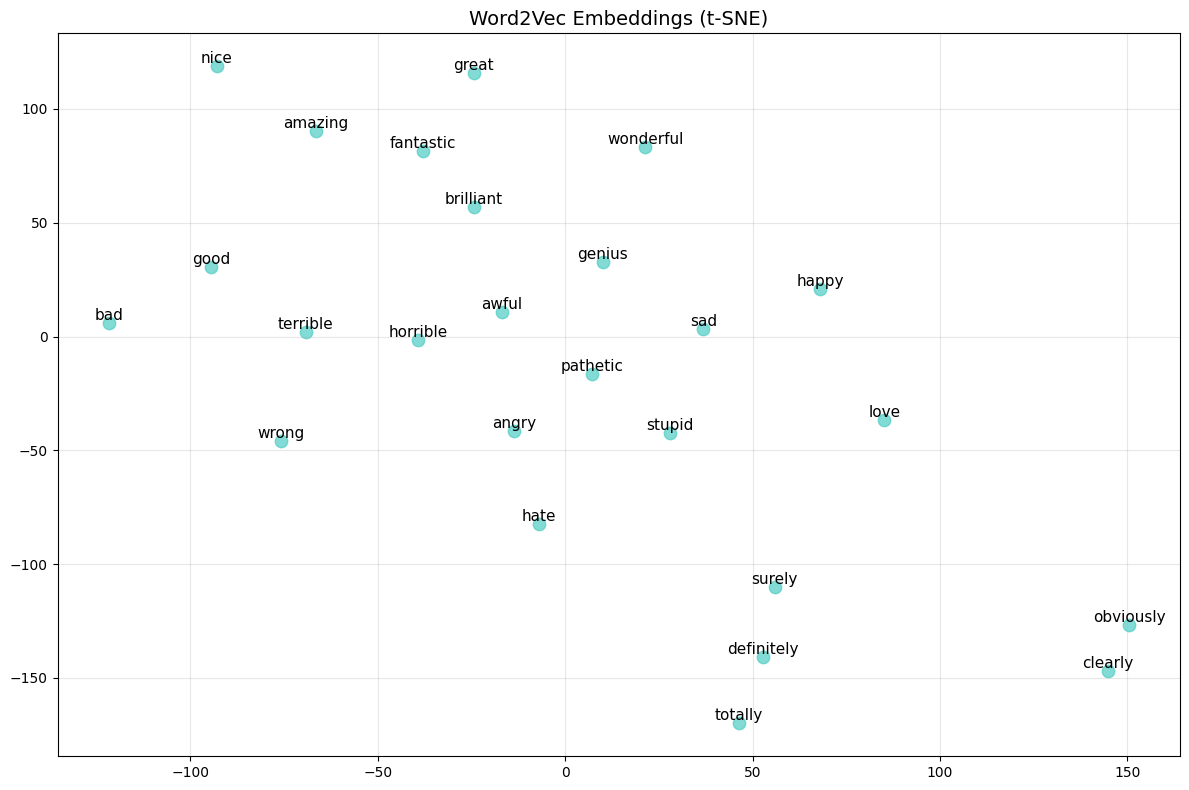

✓ Saved: word2vec_tsne.png


In [ ]:
from sklearn.manifold import TSNE

# Pick interesting words to visualize
viz_words = (['obviously', 'clearly', 'totally', 'definitely', 'surely',
              'brilliant', 'genius', 'wonderful', 'amazing', 'fantastic',
              'terrible', 'awful', 'horrible', 'stupid', 'pathetic',
              'happy', 'good', 'nice', 'great', 'love',
              'sad', 'bad', 'angry', 'hate', 'wrong'])

# Filter to words in our vocabulary
viz_words = [w for w in viz_words if w in w2v.wv]
vectors = np.array([w2v.wv[w] for w in viz_words])

# t-SNE: compress 100D → 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(viz_words)-1))
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], c='#4ECDC4', s=80, alpha=0.7)
for i, word in enumerate(viz_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]),
                 fontsize=11, ha='center', va='bottom')
plt.title('Word2Vec Embeddings (t-SNE)', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE}/outputs/word2vec_tsne.png', dpi=150)
plt.show()
print("✓ Saved: word2vec_tsne.png")

In [ ]:
MAX_LEN = 50  # truncate/pad to 50 tokens

def tokens_to_vectors(tokens):

    vecs = []
    for w in tokens[:MAX_LEN]:
        if w in w2v.wv:
            vecs.append(w2v.wv[w])
        else:
            vecs.append(np.zeros(100))  # unknown words → zero vector
    return vecs

print("Converting tokens to vectors...")
X_train_raw = train_df['tokens'].apply(tokens_to_vectors).tolist()
X_test_raw = test_df['tokens'].apply(tokens_to_vectors).tolist()

# Pad sequences to fixed length
X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN, dtype='float32',
                        padding='post', truncating='post', value=0.0)
X_test = pad_sequences(X_test_raw, maxlen=MAX_LEN, dtype='float32',
                       padding='post', truncating='post', value=0.0)

y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Converting tokens to vectors...
X_train: (160000, 50, 100), X_test: (40000, 50, 100)


In [ ]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(MAX_LEN, 100)),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train with early stopping (stop if validation loss stops improving)
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("\nTraining...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Save model
model.save(f'{DRIVE}/models/lstm_model.h5')
print("✓ LSTM model saved")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 128)        │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,769 (659.25 KB)

 Trainable params: 168,769 (659.25 KB)

 Non-trainable params: 0 (0.00 B)


Training...
Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.6363 - loss: 0.6349 - val_accuracy: 0.6658 - val_loss: 0.6163
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6601 - loss: 0.6123 - val_accuracy: 0.6693 - val_loss: 0.6020
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6662 - loss: 0.6049 - val_accuracy: 0.6695 - val_loss: 0.5978
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6717 - loss: 0.5992 - val_accuracy: 0.6723 - val_loss: 0.5999
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6771 - loss: 0.5940 - val_accuracy: 0.6758 - val_loss: 0.5921
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6807 - loss: 0.5890 - val_accuracy: 0.6804 - val_loss: 0.5918
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6850 - loss: 0.5845 - val_accuracy: 0.6814 - val_loss: 0.5912
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6894 - loss: 0.

✓ LSTM model saved


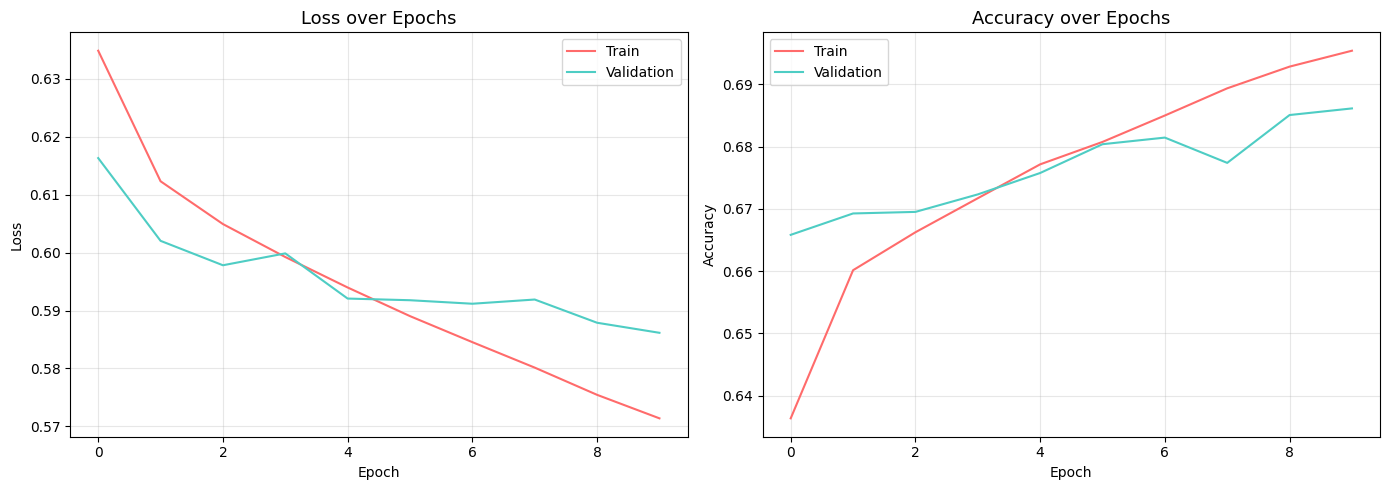

✓ Saved: lstm_training.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train', color='#FF6B6B')
axes[0].plot(history.history['val_loss'], label='Validation', color='#4ECDC4')
axes[0].set_title('Loss over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train', color='#FF6B6B')
axes[1].plot(history.history['val_accuracy'], label='Validation', color='#4ECDC4')
axes[1].set_title('Accuracy over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE}/outputs/lstm_training.png', dpi=150)
plt.show()
print("✓ Saved: lstm_training.png")

In [ ]:
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "=" * 40)
print("   LSTM + Word2Vec — RESULTS")
print("=" * 40)
print(f"  Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print("=" * 40)
print(classification_report(y_test, y_pred, target_names=['Genuine', 'Sarcastic']))


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

   LSTM + Word2Vec — RESULTS
  Accuracy:  0.6798 (68.0%)
  Precision: 0.7291
  Recall:    0.5798
  F1 Score:  0.6459
              precision    recall  f1-score   support

     Genuine       0.65      0.78      0.71     19849
   Sarcastic       0.73      0.58      0.65     20151

    accuracy                           0.68     40000
   macro avg       0.69      0.68      0.68     40000
weighted avg       0.69      0.68      0.68     40000



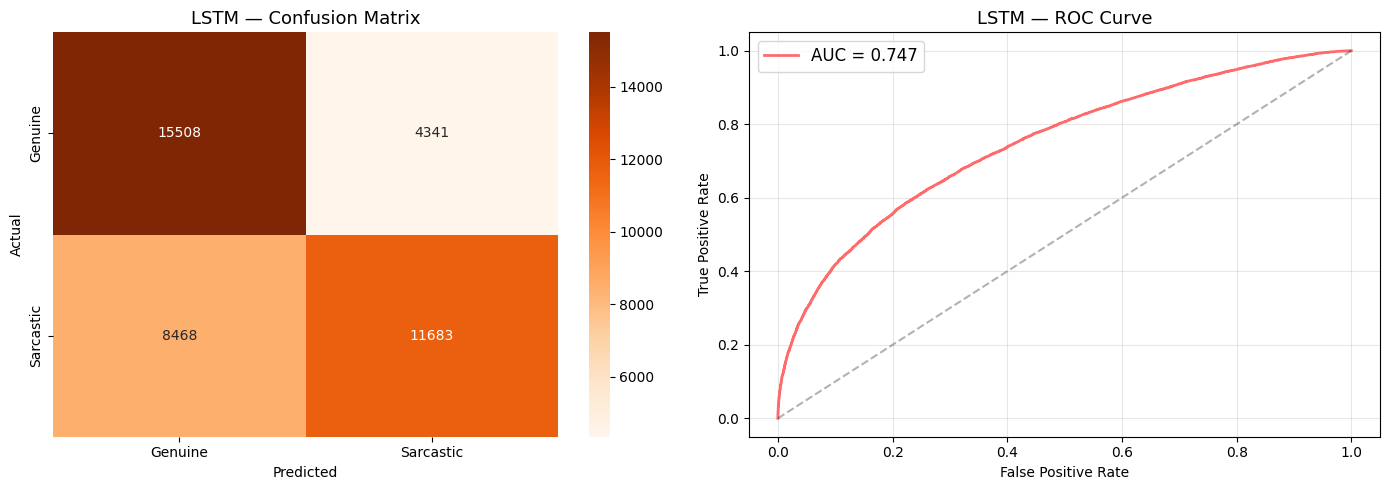

✓ Saved: lstm_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Genuine', 'Sarcastic'],
            yticklabels=['Genuine', 'Sarcastic'])
axes[0].set_title('LSTM — Confusion Matrix', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#FF6B6B', linewidth=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('LSTM — ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE}/outputs/lstm_results.png', dpi=150)
plt.show()
print("✓ Saved: lstm_results.png")

In [ ]:
metrics = {'model': 'LSTM', 'accuracy': acc, 'precision': prec,
           'recall': rec, 'f1': f1, 'auc': roc_auc}
with open(f'{DRIVE}/models/lstm_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

print("✓ Metrics saved")

✓ Metrics saved
